### Часть 1

1.1 Создали два независимых вектора: x1 — разброс маленький, $ \sigma_1 = 0.3 $ ,   x2 — разброс больше, $ \sigma_2 = 0.8 $. Затем объединили их в точки, после повотрота на точек на $ \alpha = 30^\circ $ между векторами появиласть кореляция. Выборочная ковариационная матрица получилась близкой к теоретической, что подтверждает правильность генерации данных.

Сделали автопроверку.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

M = 500
x1 = np.random.normal(0, 0.3, M) # Генерация двух независимых векторов
x2 = np.random.normal(0, 0.8, M)

X = np.column_stack((x1, x2))  # Объединяем вектора в точки
alpha = np.radians(30)
R = np.array([                      # Матрица поворота
    [np.cos(alpha), -np.sin(alpha)],
    [np.sin(alpha), np.cos(alpha)]
])
X = X @ R.T  # Поворачиваем точки

C_sample = np.cov(X.T)
C_theor = R @ np.diag([0.3**2, 0.8**2]) @ R.T
print(f'Выборочная: \n{C_sample}')
print(f'Теоритическая: \n{C_theor}')

# Автопроверка
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"

Выборочная: 
[[ 0.23050313 -0.23853284]
 [-0.23853284  0.51662443]]
Теоритическая: 
[[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]


В этой части мы визуализировали наши точки. С помощью scatter построили облако из них, а с помощью contour добавили линии равной плотности для теоретического нормального распределения. На графике видно, что облако имеет вытянутую эллиптическую форму и наклонено относительно осей координат. Это связано с разными $ \sigma $ и их корреляцией, которая появилась после поворота данных.

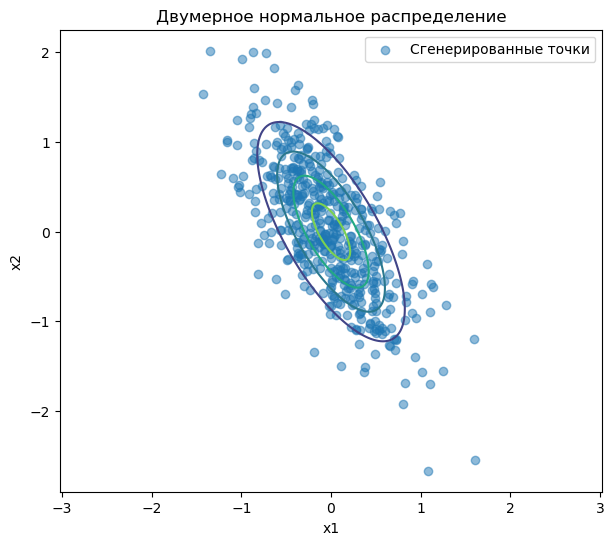

In [14]:
# Визуализация
from scipy.stats import multivariate_normal

plt.figure(figsize=(7, 6))
plt.scatter(
    X[:, 0],
    X[:, 1],
    alpha=0.5,
    label="Сгенерированные точки"
)
xx, yy = np.meshgrid(        # Сетка координат
    np.linspace(-2, 2, 200),
    np.linspace(-2, 2, 200)
)
rv = multivariate_normal(mean=[0, 0], cov=C_theor) 
grid = np.column_stack((xx.ravel(), yy.ravel()))

pdf = rv.pdf(grid)          # Вычисляем плотность в каждой точке
pdf = pdf.reshape(xx.shape)

plt.contour(        # Рисуем линии равной плотности
    xx,
    yy,
    pdf,
    levels=5
)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title("Двумерное нормальное распределение")
plt.legend()
plt.axis("equal")
plt.show()

1.2 Cгенерировали второй набор из 500 точек с помощью 'np.random.multivariate_normal', используя те же среднее и ковариационную матрицу, что и в 1.1. 

Два облака точек имеют примерно одинаковую форму, ориентацию и разброс, хотя отдельные точки отличаются. Различия возникают из-за случайности при генерации выборки.

**Почему встроенная функция удобнее:** 'np.random.multivariate_normal' позволяет сразу задать среднее и ковариацию, поэтому не требуется самостоятельно генерировать их отдельно и выполнять поворот матрицей R. Код короче и меньше вероятность ошибки.

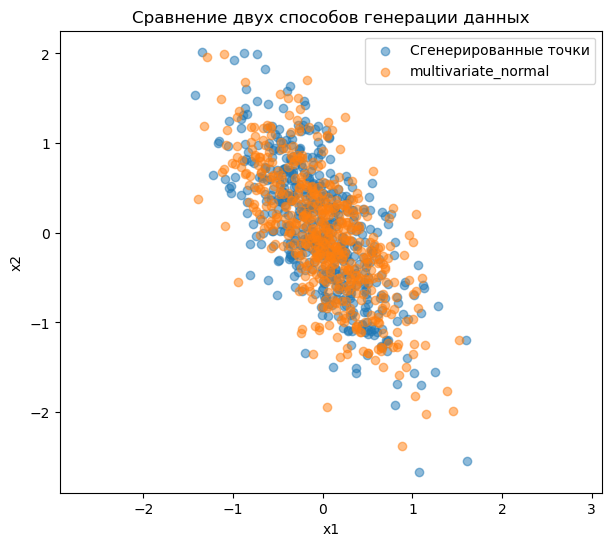

In [15]:
X_new = np.random.multivariate_normal(mean=[0, 0], cov=C_theor, size=M)

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, label="Сгенерированные точки")
plt.scatter(X_new[:, 0], X_new[:, 1], alpha=0.5, label="multivariate_normal")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Сравнение двух способов генерации данных")
plt.legend()
plt.axis("equal")
plt.show()

### Часть 2

Оценили среднее и ковариационную матрицу по нашим точкам. Выяснили, что среднее находится близко к (0, 0), а выборочная ковариационная матрица близка к теоретической.

In [22]:
mu_hat = np.mean(X, axis=0)
C_hat = np.cov(X.T)
print(f'Оценка среднего: \n{mu_hat}')
print(f'Оценка ковариационной матрицы: \n{C_hat}')


Оценка среднего: 
[-0.0348813   0.04007317]
Оценка ковариационной матрицы: 
[[ 0.23050313 -0.23853284]
 [-0.23853284  0.51662443]]


Плотность распределения получили двумя способами. Первый способ — с помощью готовой функции 'multivariate_normal' из 'scipy.stats', которой передали оценённые среднее mu_hat и ковариационную матрицу C_hat. Второй способ — самостоятельно реализовали вычисление плотности по формуле многомерного нормального распределения: сначала нашли определитель и обратную матрицу ковариационной матрицы, затем для каждой точки сетки вычислили отклонение от среднего и подставили эти значения в формулу (реализацию вычислений по формуле выполнили с помощью ИИ)

Значения плотности, полученные обоими способами, практически совпали, а проверка np.allclose дала True

In [23]:
# сетку создали в 1.1, поэтому переходим к плотности
# С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`
distribution = multivariate_normal(mean=mu_hat, cov=C_hat)
pdf_scipy = distribution.pdf(grid)
pdf_scipy = pdf_scipy.reshape(xx.shape)

# по формуле
det_C = np.linalg.det(C_hat)
inv_C = np.linalg.inv(C_hat)
diff = grid - mu_hat
quadratic = np.sum((diff @ inv_C) * diff, axis=1)

pdf_manual = (1 / (2 * np.pi * np.sqrt(det_C)) * np.exp(-0.5 * quadratic))
pdf_manual = pdf_manual.reshape(xx.shape)

# сравнение 
max_diff = np.max(np.abs(pdf_scipy - pdf_manual))
print('Максимальная разница:', max_diff)
print('Результаты совпадают:', np.allclose(pdf_scipy, pdf_manual, atol=1e10))

Максимальная разница: 1.6653345369377348e-16
Результаты совпадают: True


Построили карту оценённой плотности распределения и наложили на неё исходные 500 точек.
Максимальная плотность расположена около центра облака точек, а линии одинаковой плотности образуют вытянутые и повернутые эллипсы.

Добавили автопроверку

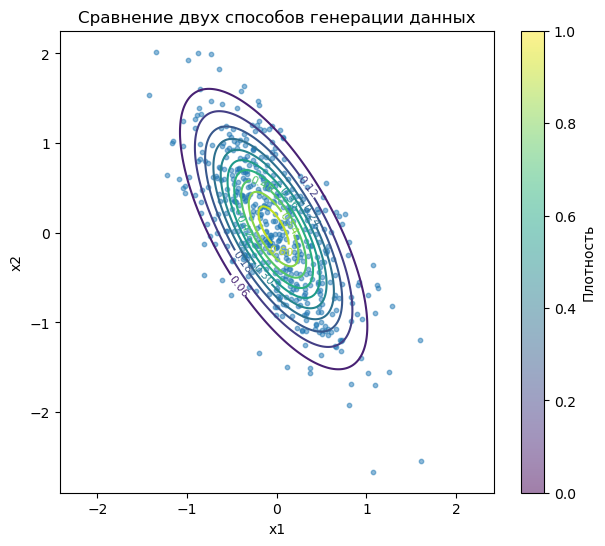

In [27]:
# визуализация
plt.figure(figsize=(7, 6))
contours = plt.contour(xx, yy, pdf_scipy, levels=10) # линии одинаковой плотности
plt.clabel(contours, inline=True, fontsize=8)

plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.5)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Сравнение двух способов генерации данных")
plt.axis("equal")
plt.colorbar(label="Плотность")
plt.show()

# Автопроверка
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"

### Часть 3

Cгенерировали два класса с разными средними и ковариационными матрицами и построили байесовскую границу по разности взвешенных плотностей. 

**Граница** разделяет области, в которых классификатор выбирает разные классы, и в общем случае **имеет нелинейную форму.**

**Почему?**  ковариационные матрицы классов различаются, поэтому квадратичные члены в условии равенства плотностей не сокращаются.


P(y=0) = 0.5
P(y=1) = 0.5


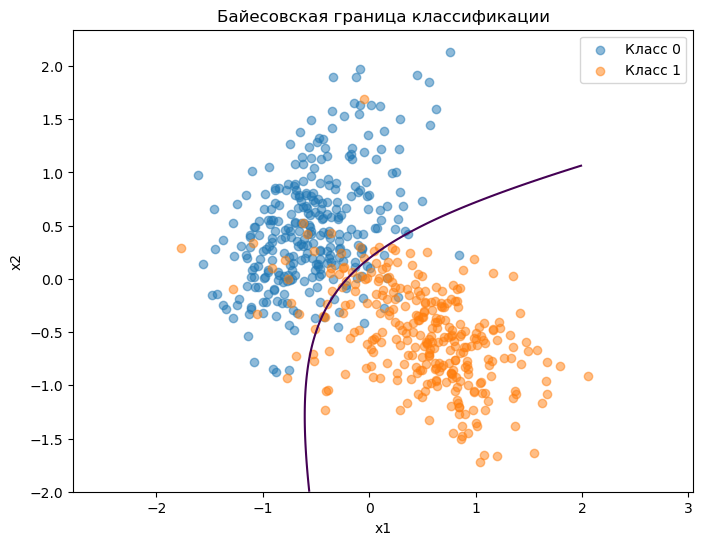

In [31]:
n = 300,
mu0 = np.array([-0.5, 0.5])   # Класс 0
c0 = np.array([[0.2, 0.1],    
      [0.1, 0.3]])
mu1 = np.array([0.5, -0.5])   # Класс 1
c1 = np.array([[0.3, -0.1],
      [-0.1, 0.2]])

X0 = np.random.multivariate_normal(mu0, c0, n)  # 300 точек класса 0
X1 = np.random.multivariate_normal(mu1, c1, n)  # 300 точек класса 1

# апостериорная вероятность
X_all = np.vstack((X0, X1))
y_all = np.hstack((np.zeros(n), np.ones(n)))
p0 = np.mean(y_all == 0)
p1 = np.mean(y_all == 1)
print('P(y=0) =', p0)
print('P(y=1) =', p1)
# плотность каждого класса
dist_0 = multivariate_normal(mean=mu0, cov=c0)
dist_1 = multivariate_normal(mean=mu1, cov=c1)
# используем новую сетку (в прошлой будет тесно)
x_grid = np.linspace(-2, 2, 300)
y_grid = np.linspace(-2, 2, 300)
xx3, yy3 = np.meshgrid(x_grid, y_grid)
grid3 = np.column_stack((xx3.ravel(), yy3.ravel()))

pdf0 = dist_0.pdf(grid3)
pdf1 = dist_1.pdf(grid3)

delta = pdf0 *p0 - pdf1 * p1   # формула из тз
delta = delta.reshape(xx3.shape)

# визуализация
plt.figure(figsize=(8, 6))
plt.contour(xx3, yy3, delta, levels=[0])    # линия(граница)
plt.scatter(X0[:, 0], X0[:, 1], alpha=0.5, label="Класс 0")
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.5, label="Класс 1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Байесовская граница классификации")
plt.legend()
plt.axis("equal")
plt.show()

### Часть 4


In [ ]:
from sklearn.base import BaseEstimator

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b
    
    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """
        # 1. Сохранить уникальные классы
        # 2. Для каждого класса: вычислить mean и prior
        # 3. Вычислить общую ковариационную матрицу (усредненную по классам)
        # 4. Вычислить w и b
        pass
    
    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        pass
    
    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""
        pass



from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
my_lda = MyLDA().fit(X_train, y_train)
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
assert np.abs(my_lda.coef_ @ sk_lda.coef_ - 1) < 1e-6, "Вектора весов сонаправлены, но разной длины"
```